# 1. Exploración de Datos — Predicting Irrigation Need

Problema de clasificación multiclase: predecir la necesidad de riego (`Low` / `Medium` / `High`).

Se realiza exploración tabular y visual del dataset de entrenamiento para entender
la distribución de variables, relaciones con el target, y detectar posibles issues de calidad.

**Dataset:** Playground Series S6E4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

continuas = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity",
    "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours",
    "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"
]

categoricas = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
    "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"
]

TARGET      = "Irrigation_Need"
CLASS_ORDER = ["Low", "Medium", "High"]
PALETTE     = {"Low": "steelblue", "Medium": "goldenrod", "High": "tomato"}

print(f"Train: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Variables continuas:   {len(continuas)}")
print(f"Variables categoricas: {len(categoricas)}")

Train: 630,000 filas x 21 columnas
Test:  270,000 filas x 20 columnas
Variables continuas:   11
Variables categoricas: 8


In [3]:
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 2. Visión General del Dataset

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [5]:
train[continuas].describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [6]:
print("Valores nulos por columna:")
print(train.isnull().sum())
print(f"\nFilas duplicadas (excluyendo id): {train.drop(columns='id').duplicated().sum():,}")

Valores nulos por columna:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

Filas duplicadas (excluyendo id): 0


## 3. Distribución del Target

DISTRIBUCIÓN DEL TARGET
  Low     : 369,917  (58.72%)
  Medium  : 239,074  (37.95%)
  High    :  21,009  (3.33%)


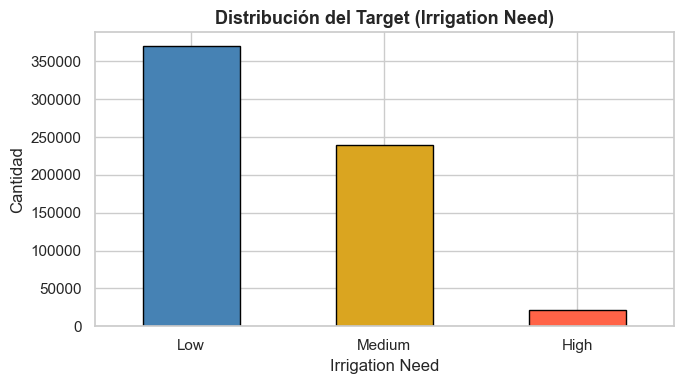

In [7]:
counts = train[TARGET].value_counts().reindex(CLASS_ORDER)
props  = train[TARGET].value_counts(normalize=True).reindex(CLASS_ORDER)

print(f"{'='*45}")
print("DISTRIBUCIÓN DEL TARGET")
print(f"{'='*45}")
for cls in CLASS_ORDER:
    print(f"  {cls:8s}: {counts[cls]:>7,}  ({props[cls]*100:.2f}%)")
print(f"{'='*45}")

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot.bar(ax=ax, color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
ax.set_title("Distribución del Target (Irrigation Need)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Irrigation Need")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Variables Continuas

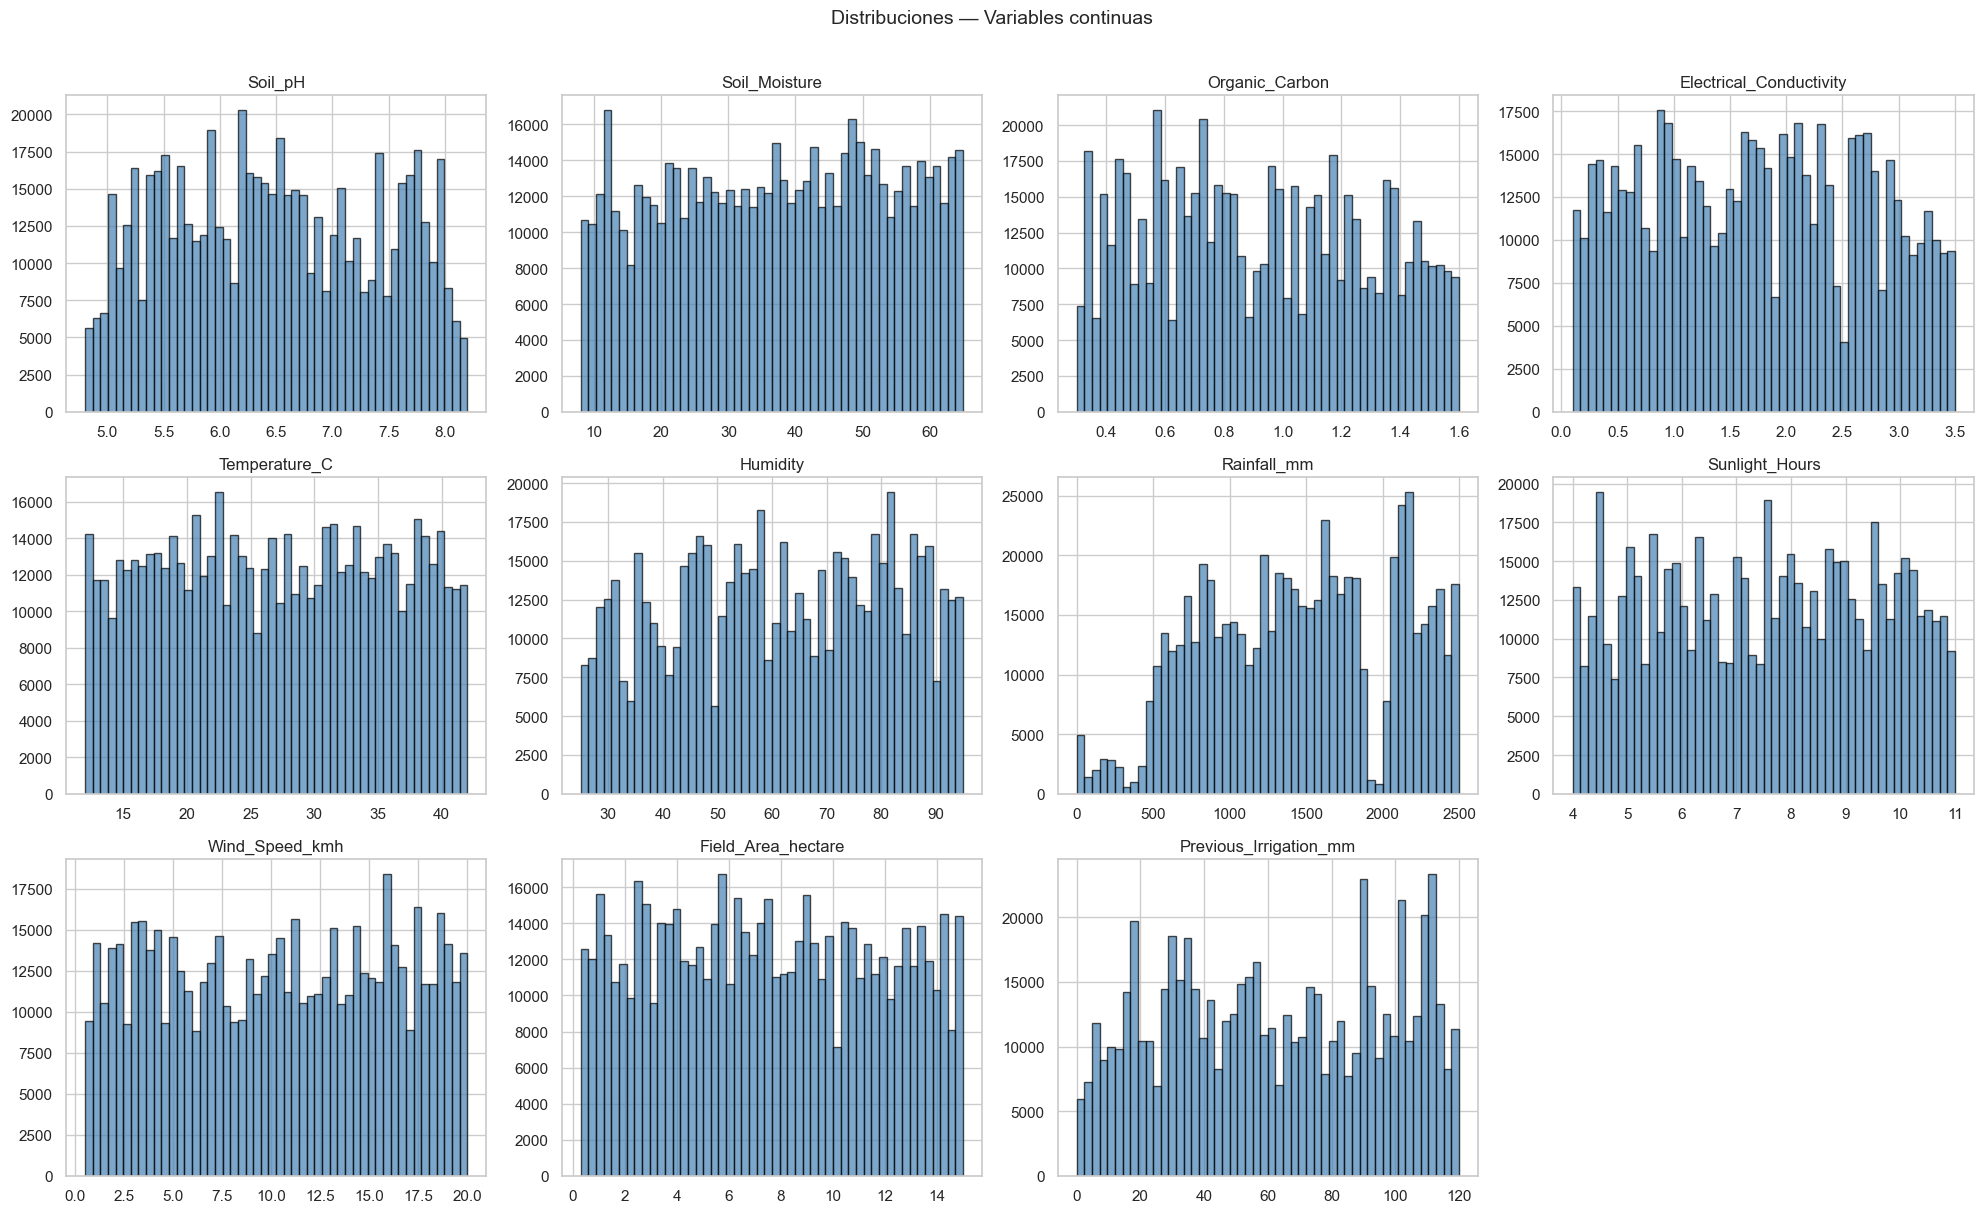

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, continuas):
    train[col].hist(bins=50, ax=ax, color="steelblue", edgecolor="black", alpha=0.7)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle("Distribuciones — Variables continuas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

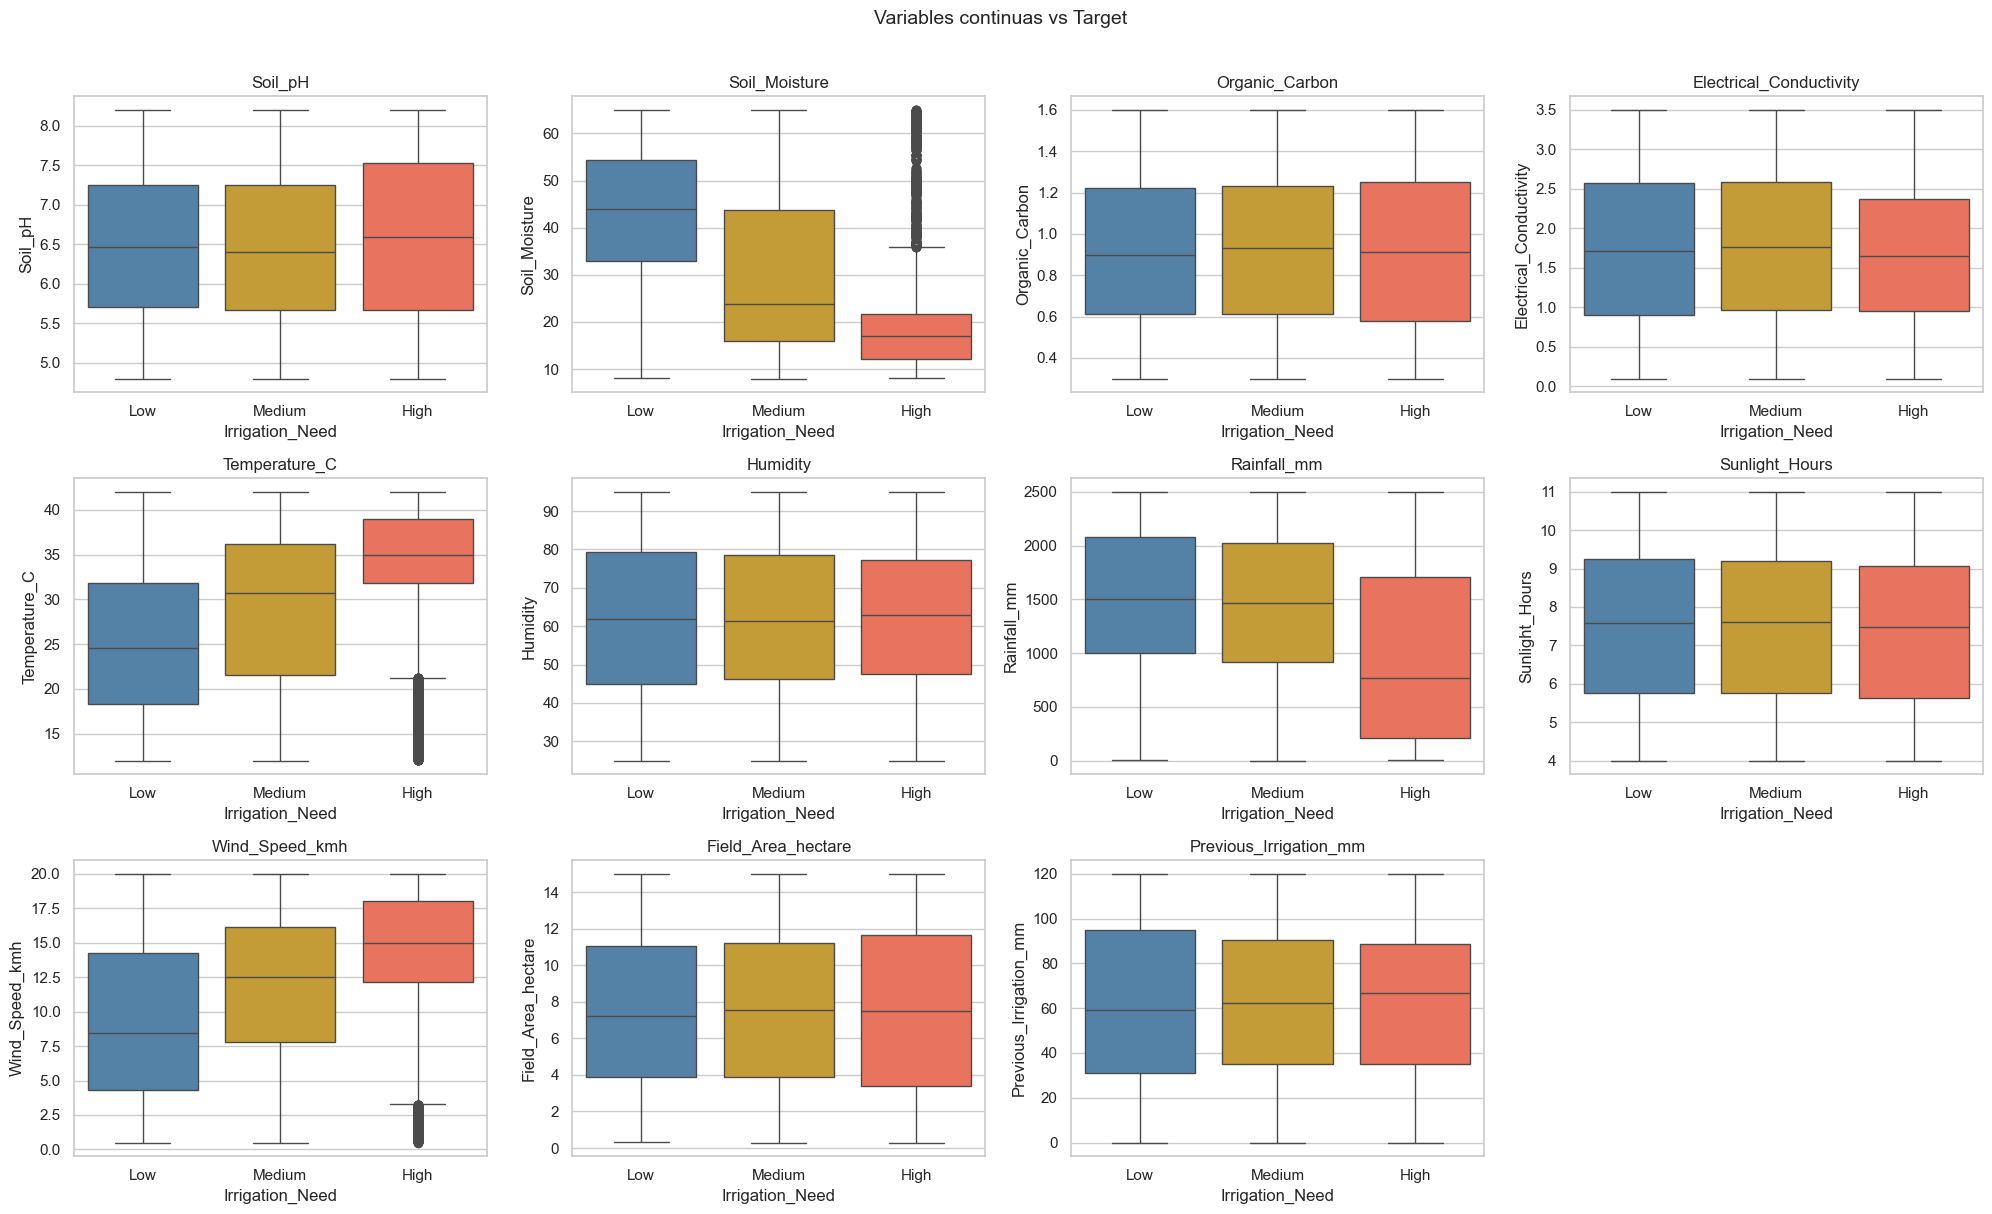

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
for ax, col in zip(axes.flat, continuas):
    sns.boxplot(data=train, x=TARGET, y=col, order=CLASS_ORDER,
                palette=PALETTE, ax=ax)
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle("Variables continuas vs Target", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Variables Categóricas

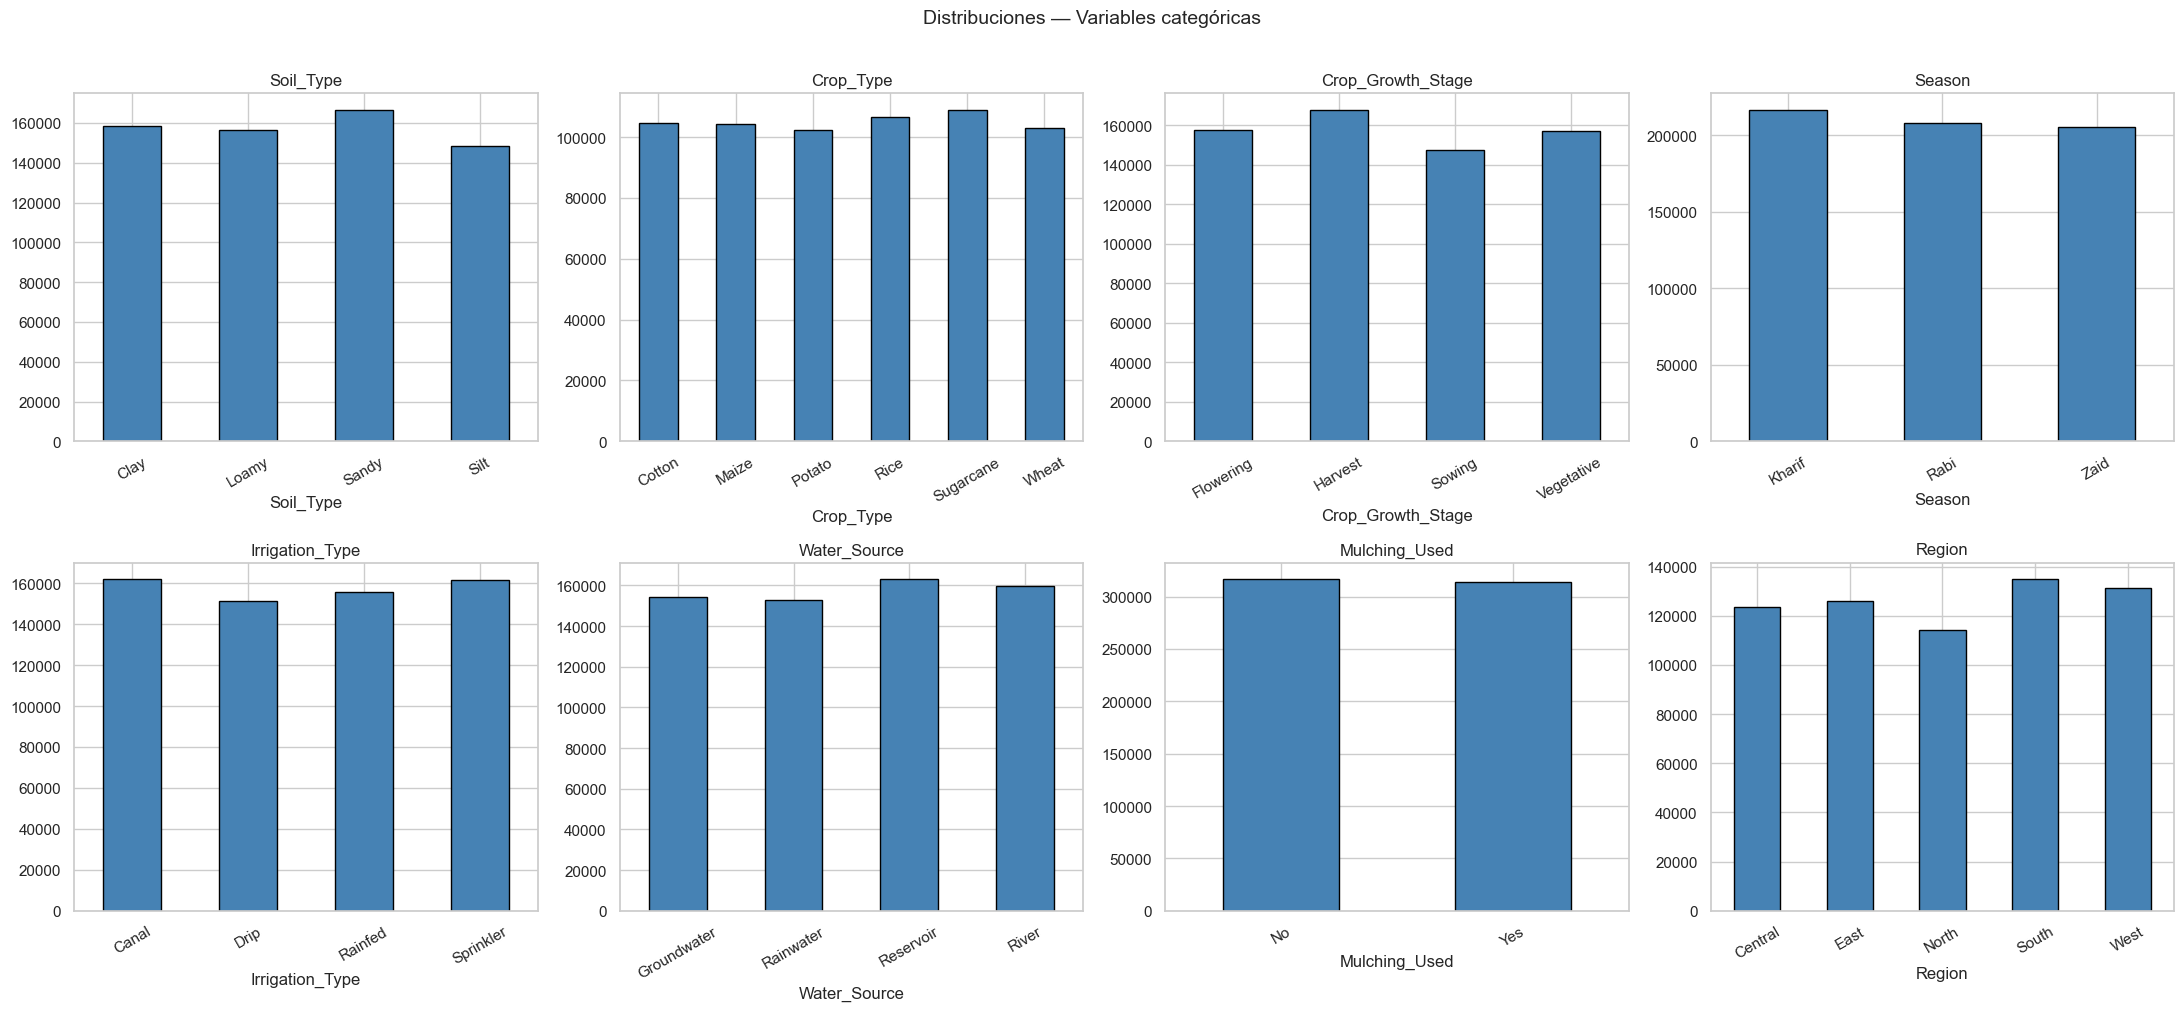

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, col in zip(axes.flat, categoricas):
    train[col].value_counts().sort_index().plot.bar(ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle("Distribuciones — Variables categóricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

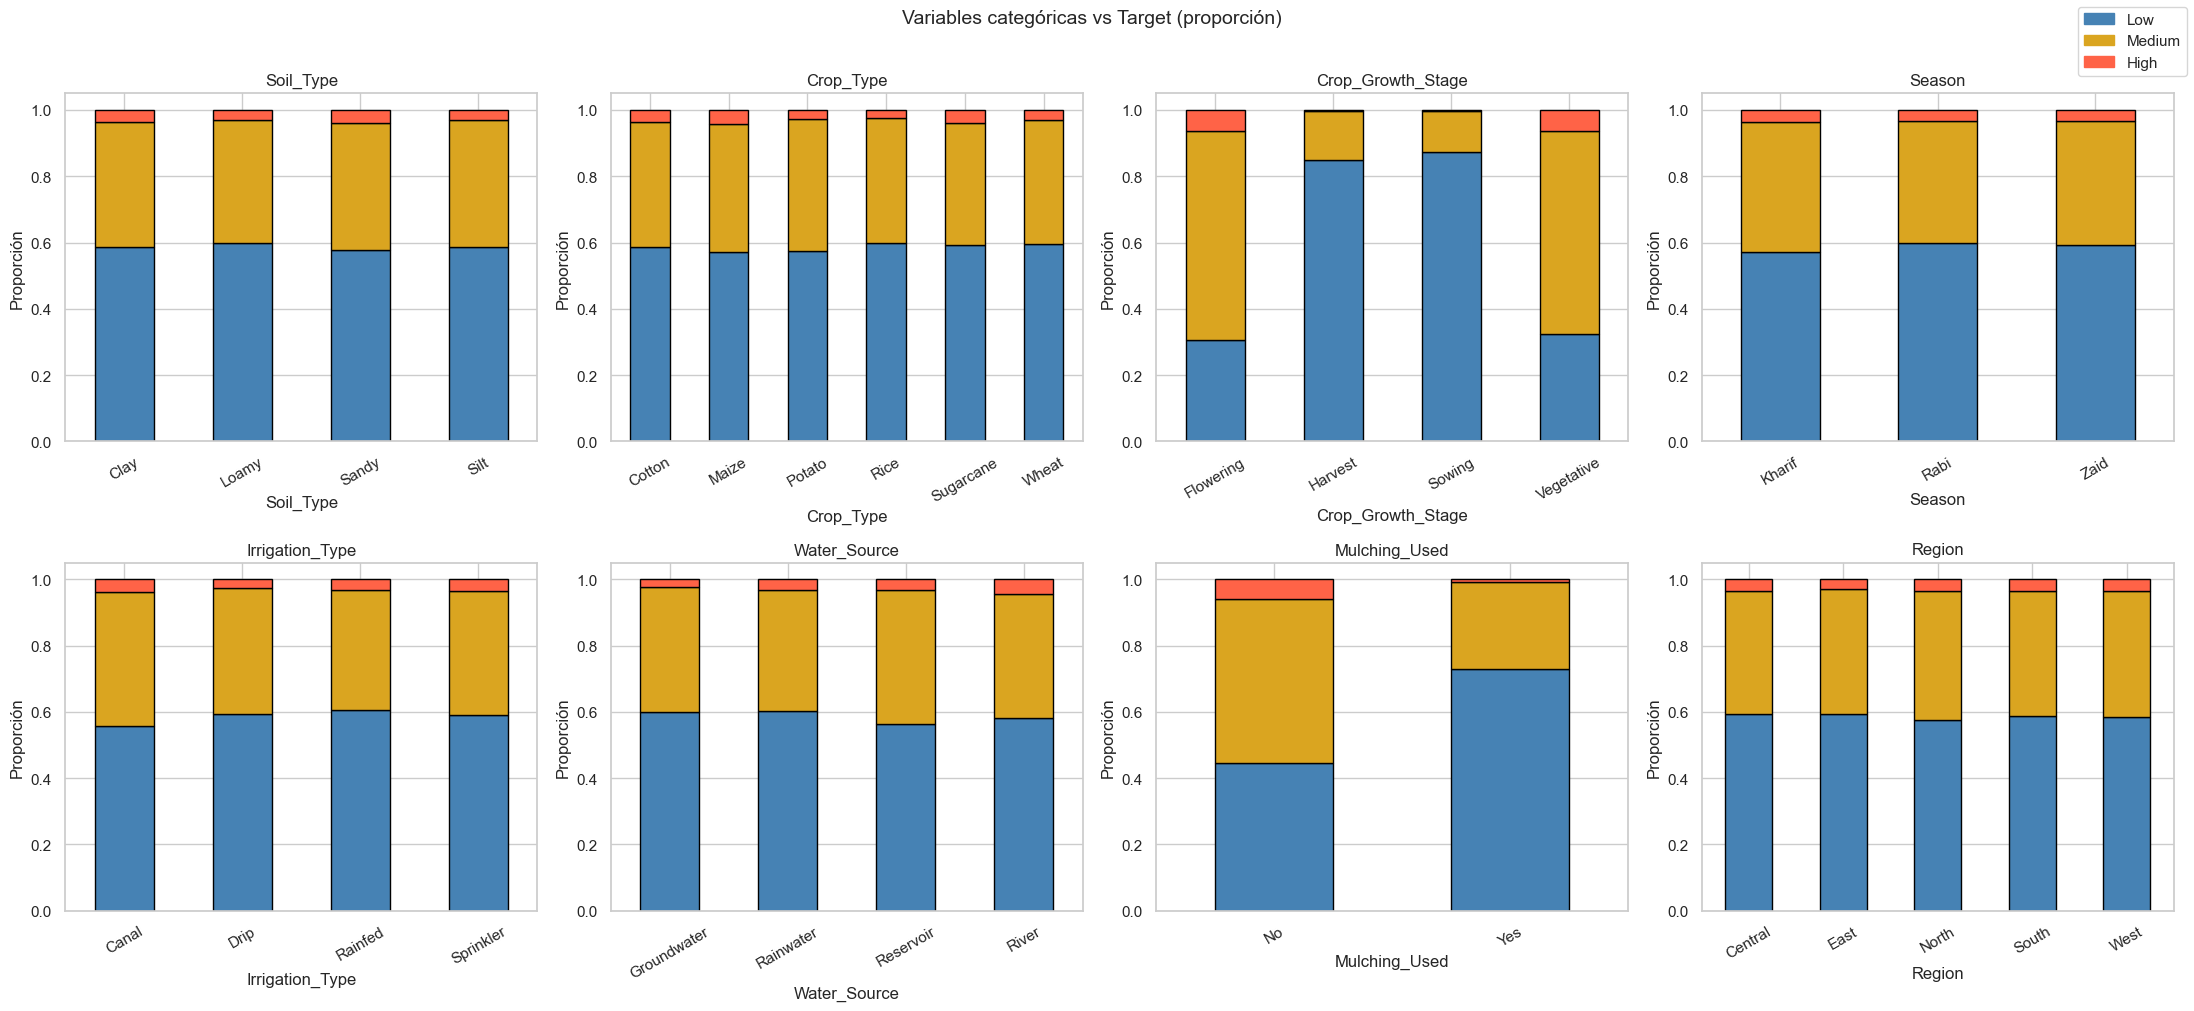

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, col in zip(axes.flat, categoricas):
    props = (
        train.groupby(col)[TARGET]
             .value_counts(normalize=True)
             .unstack(fill_value=0)
             .reindex(columns=CLASS_ORDER, fill_value=0)
    )
    props.plot.bar(stacked=True, ax=ax,
                   color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="black")
    ax.set_title(col)
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=30)
    ax.legend([], frameon=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[c]) for c in CLASS_ORDER]
fig.legend(handles, CLASS_ORDER, loc="upper right", fontsize=11)
plt.suptitle("Variables categóricas vs Target (proporción)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlaciones

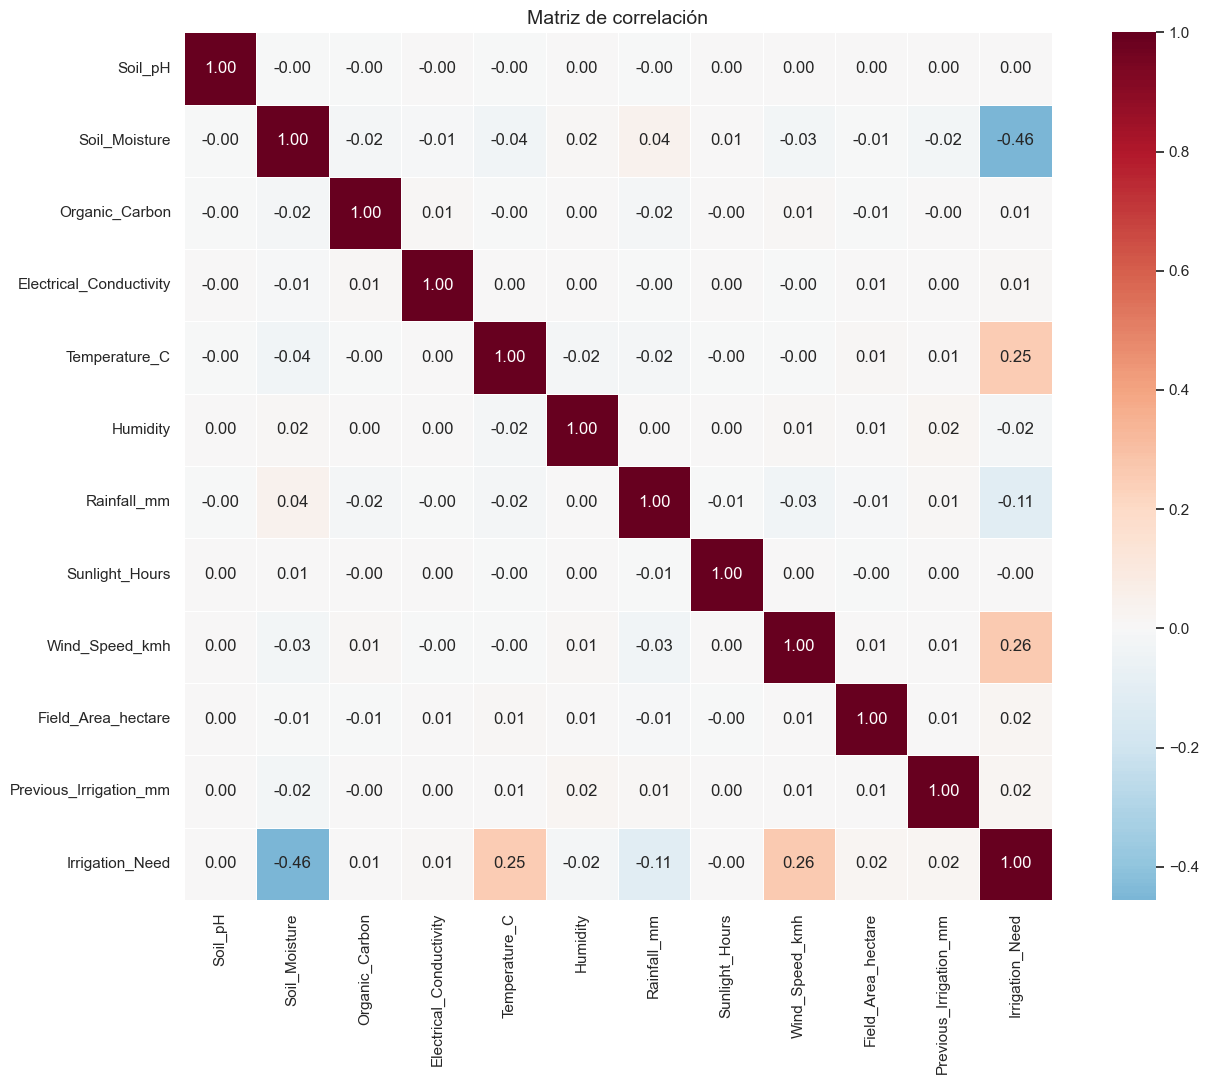

In [12]:
df_corr = train[continuas + [TARGET]].copy()
df_corr[TARGET] = df_corr[TARGET].map({"Low": 0, "Medium": 1, "High": 2})
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
print("Correlación con Irrigation_Need (absoluta, ordenada):")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(4))

Correlación con Irrigation_Need (absoluta, ordenada):
Soil_Moisture              0.4555
Wind_Speed_kmh             0.2582
Temperature_C              0.2529
Rainfall_mm                0.1115
Humidity                   0.0219
Previous_Irrigation_mm     0.0196
Field_Area_hectare         0.0177
Electrical_Conductivity    0.0108
Organic_Carbon             0.0065
Sunlight_Hours             0.0003
Soil_pH                    0.0002
Name: Irrigation_Need, dtype: float64


## 7. Conclusiones